In [6]:
import math
import csv

def format_angle(k):
    if k == 0:
        return "0"
    elif k == 1:
        return "π/6"
    else:
        return f"{k}π/6"

with open("sin_values.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    
    header = ["k", "angle (fraction of π)", "sin(x)"]
    writer.writerow(header)
    print(",".join(header))  # print header
    
    for k in range(49):
        angle = (k * math.pi) / 6
        sin_value = round(math.sin(angle), 6)
        
        if abs(sin_value) < 1e-10:
            sin_value = 0.0
        
        row = [k, format_angle(k), sin_value]
        writer.writerow(row)
        print(f"{row[0]},{row[1]},{row[2]}")  # print row

print("CSV file extended to 8π created.")

k,angle (fraction of π),sin(x)
0,0,0.0
1,π/6,0.5
2,2π/6,0.866025
3,3π/6,1.0
4,4π/6,0.866025
5,5π/6,0.5
6,6π/6,0.0
7,7π/6,-0.5
8,8π/6,-0.866025
9,9π/6,-1.0
10,10π/6,-0.866025
11,11π/6,-0.5
12,12π/6,0.0
13,13π/6,0.5
14,14π/6,0.866025
15,15π/6,1.0
16,16π/6,0.866025
17,17π/6,0.5
18,18π/6,0.0
19,19π/6,-0.5
20,20π/6,-0.866025
21,21π/6,-1.0
22,22π/6,-0.866025
23,23π/6,-0.5
24,24π/6,0.0
25,25π/6,0.5
26,26π/6,0.866025
27,27π/6,1.0
28,28π/6,0.866025
29,29π/6,0.5
30,30π/6,0.0
31,31π/6,-0.5
32,32π/6,-0.866025
33,33π/6,-1.0
34,34π/6,-0.866025
35,35π/6,-0.5
36,36π/6,0.0
37,37π/6,0.5
38,38π/6,0.866025
39,39π/6,1.0
40,40π/6,0.866025
41,41π/6,0.5
42,42π/6,0.0
43,43π/6,-0.5
44,44π/6,-0.866025
45,45π/6,-1.0
46,46π/6,-0.866025
47,47π/6,-0.5
48,48π/6,0.0
CSV file extended to 8π created.


In [7]:
import math
import csv

def format_angle(k):
    if k == 0:
        return "0"
    elif k == 1:
        return "π/6"
    else:
        return f"{k}π/6"

with open("cos_values.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    
    header = ["k", "angle (fraction of π)", "cos(x)"]
    writer.writerow(header)
    print(",".join(header))  # print header
    
    for k in range(49):
        angle = (k * math.pi) / 6
        cos_value = round(math.cos(angle), 6)
        
        if abs(cos_value) < 1e-10:
            cos_value = 0.0
        
        row = [k, format_angle(k), cos_value]
        writer.writerow(row)
        print(f"{row[0]},{row[1]},{row[2]}")  # print row

print("CSV file 'cos_values.csv' has been created.")

k,angle (fraction of π),cos(x)
0,0,1.0
1,π/6,0.866025
2,2π/6,0.5
3,3π/6,0.0
4,4π/6,-0.5
5,5π/6,-0.866025
6,6π/6,-1.0
7,7π/6,-0.866025
8,8π/6,-0.5
9,9π/6,0.0
10,10π/6,0.5
11,11π/6,0.866025
12,12π/6,1.0
13,13π/6,0.866025
14,14π/6,0.5
15,15π/6,0.0
16,16π/6,-0.5
17,17π/6,-0.866025
18,18π/6,-1.0
19,19π/6,-0.866025
20,20π/6,-0.5
21,21π/6,0.0
22,22π/6,0.5
23,23π/6,0.866025
24,24π/6,1.0
25,25π/6,0.866025
26,26π/6,0.5
27,27π/6,0.0
28,28π/6,-0.5
29,29π/6,-0.866025
30,30π/6,-1.0
31,31π/6,-0.866025
32,32π/6,-0.5
33,33π/6,0.0
34,34π/6,0.5
35,35π/6,0.866025
36,36π/6,1.0
37,37π/6,0.866025
38,38π/6,0.5
39,39π/6,0.0
40,40π/6,-0.5
41,41π/6,-0.866025
42,42π/6,-1.0
43,43π/6,-0.866025
44,44π/6,-0.5
45,45π/6,0.0
46,46π/6,0.5
47,47π/6,0.866025
48,48π/6,1.0
CSV file 'cos_values.csv' has been created.


# Sinx vs Sinx

In [10]:
import csv
import numpy as np

# Read sin values from CSV
sin_values = []

with open("sin_values.csv", "r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        sin_values.append(float(row["sin(x)"]))

model_valid = np.array(sin_values)
ref_valid = np.array(sin_values)

# IOA (Willmott 1981)
numerator = np.sum((model_valid - ref_valid) ** 2)

denominator = np.sum(
    (np.abs(model_valid - np.mean(ref_valid)) +
     np.abs(ref_valid - np.mean(ref_valid))) ** 2
)

ioa = 1 - numerator / denominator if denominator != 0 else np.nan

print(ioa)

1.0


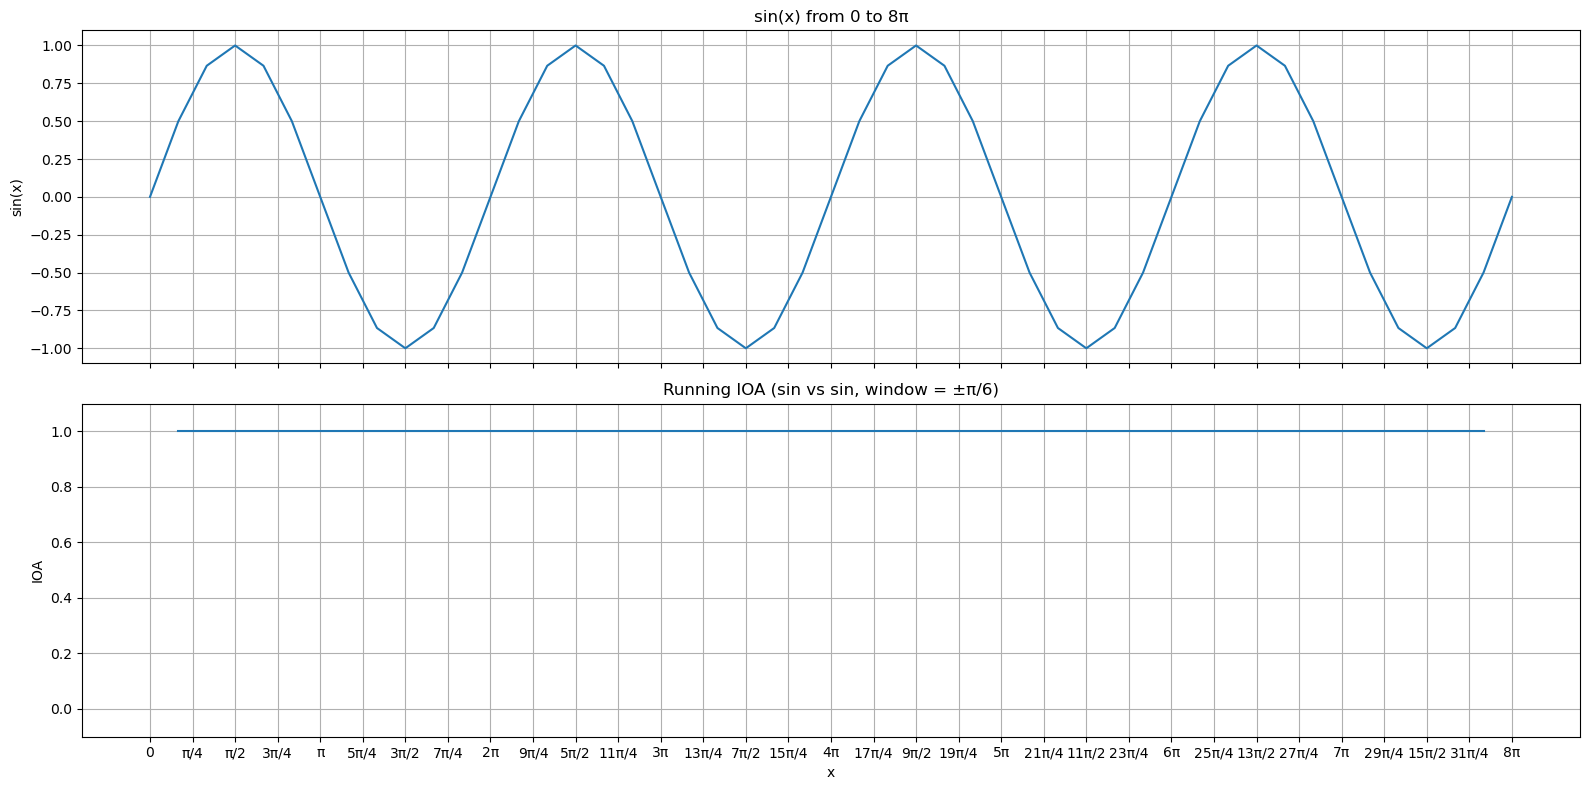

In [29]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ----------------------------
# Generate sin(x)
# ----------------------------
k_vals = np.arange(49)
x_vals = k_vals * math.pi / 6
sin_vals = np.sin(x_vals)

# ----------------------------
# Running IOA (±π/6 window)
# ----------------------------
ioa_vals = []

for i in range(len(sin_vals)):
    if i == 0 or i == len(sin_vals) - 1:
        ioa_vals.append(np.nan)
        continue

    model = sin_vals[i-1:i+2]
    ref = sin_vals[i-1:i+2]

    numerator = np.sum((model - ref) ** 2)
    denominator = np.sum(
        (np.abs(model - np.mean(ref)) +
         np.abs(ref - np.mean(ref))) ** 2
    )

    ioa = 1 - numerator / denominator if denominator != 0 else np.nan
    ioa_vals.append(ioa)

ioa_vals = np.array(ioa_vals)

# ----------------------------
# Plotting (aligned x-axis, no cut-off)
# ----------------------------
fig, axs = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: sin(x)
axs[0].plot(x_vals, sin_vals)
axs[0].set_title("sin(x) from 0 to 8π")
axs[0].set_ylabel("sin(x)")
axs[0].grid(True)

# Bottom: running IOA
axs[1].plot(x_vals, ioa_vals)
axs[1].set_title("Running IOA (sin vs sin, window = ±π/6)")
axs[1].set_xlabel("x")
axs[1].set_ylabel("IOA")
axs[1].set_ylim(-0.1, 1.1)
axs[1].grid(True)

import matplotlib.ticker as ticker

# Define tick positions (0 to 8π in steps of π/4)
pi = math.pi
ticks = np.arange(0, 8*pi + pi/4, pi/4)

# Function to format labels as fractions of π
def format_pi_label(x):
    frac = x / pi
    if frac == 0:
        return "0"
    elif frac == 1:
        return "π"
    elif frac.is_integer():
        return f"{int(frac)}π"
    else:
        # convert to fraction like 1/4, 3/2, etc.
        from fractions import Fraction
        f = Fraction(frac).limit_denominator(8)
        if f.numerator == 1:
            return f"π/{f.denominator}"
        elif f.denominator == 1:
            return f"{f.numerator}π"
        else:
            return f"{f.numerator}π/{f.denominator}"

labels = [format_pi_label(t) for t in ticks]

# Apply to BOTH subplots
axs[0].set_xticks(ticks)
axs[0].set_xticklabels(labels)

axs[1].set_xticks(ticks)
axs[1].set_xticklabels(labels)

plt.tight_layout()
plt.show()

# Sinx vs -Sinx

In [38]:
## Sinx

import csv
import numpy as np

# Read sin values from CSV
sin_values = []

with open("sin_values.csv", "r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        sin_values.append(float(row["sin(x)"]))

model_valid = np.array(sin_values)
ref_valid = -np.array(sin_values)  # negate for comparison

# IOA (Willmott 1981)
numerator = np.sum((model_valid - ref_valid) ** 2)

denominator = np.sum(
    (np.abs(model_valid - np.mean(ref_valid)) +
     np.abs(ref_valid - np.mean(ref_valid))) ** 2
)

ioa = 1 - numerator / denominator if denominator != 0 else np.nan

print(ioa)

0.0


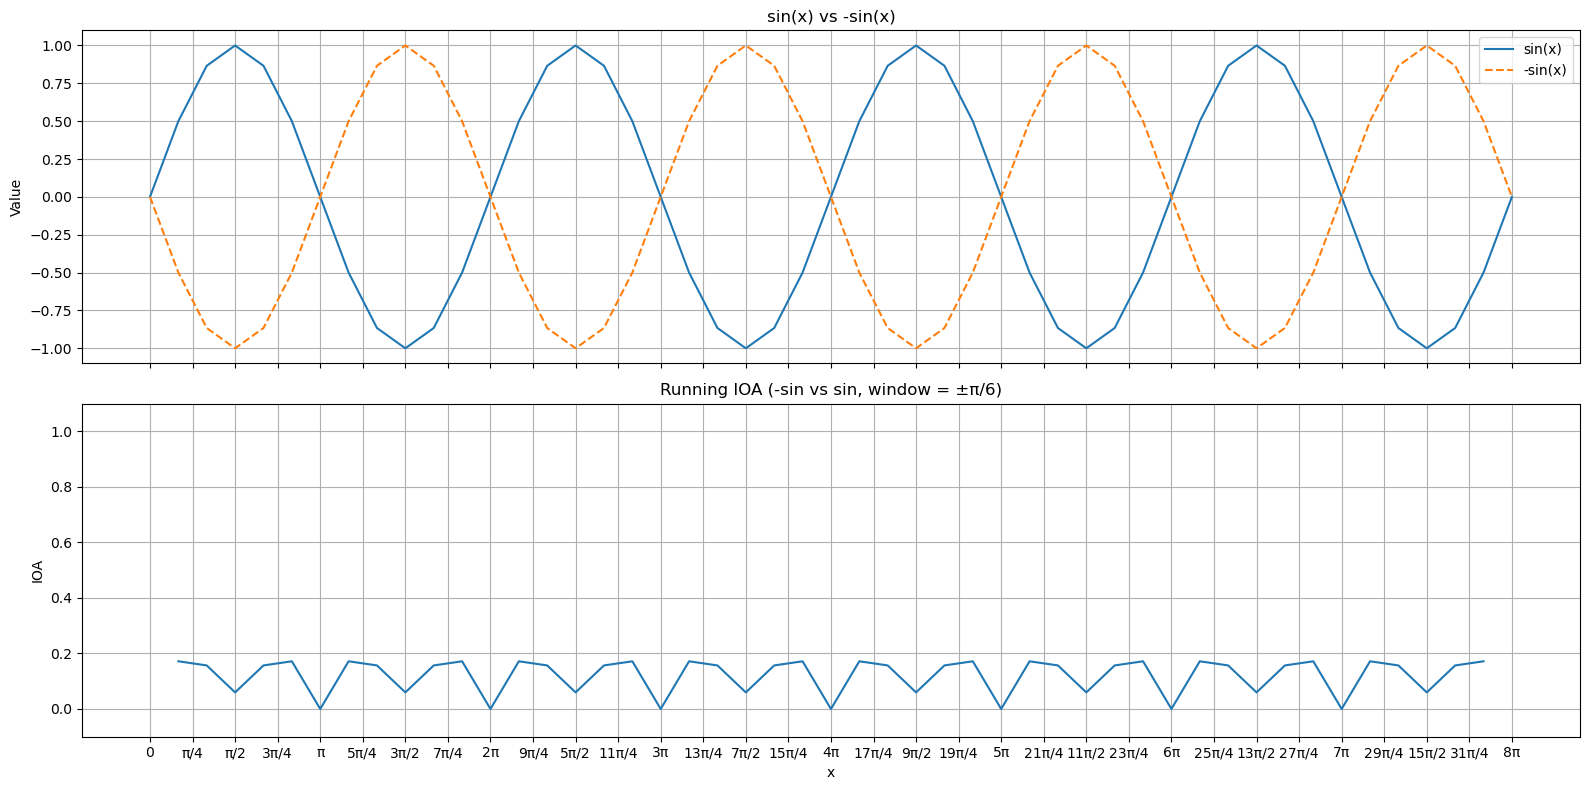

In [28]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ----------------------------
# Generate sin(x)
# ----------------------------
k_vals = np.arange(49)
x_vals = k_vals * math.pi / 6

sin_vals = np.sin(x_vals)
neg_sin_vals = -sin_vals

# ----------------------------
# Running IOA (±π/6 window)
# ----------------------------
ioa_vals = []

for i in range(len(sin_vals)):
    if i == 0 or i == len(sin_vals) - 1:
        ioa_vals.append(np.nan)
        continue

    model = neg_sin_vals[i-1:i+2]
    ref = sin_vals[i-1:i+2]

    numerator = np.sum((model - ref) ** 2)
    denominator = np.sum(
        (np.abs(model - np.mean(ref)) +
         np.abs(ref - np.mean(ref))) ** 2
    )

    ioa = 1 - numerator / denominator if denominator != 0 else np.nan
    ioa_vals.append(ioa)

ioa_vals = np.array(ioa_vals)

# ----------------------------
# Plotting (aligned x-axis, no cropping)
# ----------------------------
fig, axs = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: sin and -sin
axs[0].plot(x_vals, sin_vals, label="sin(x)")
axs[0].plot(x_vals, neg_sin_vals, label="-sin(x)", linestyle="--")
axs[0].set_title("sin(x) vs -sin(x)")
axs[0].set_ylabel("Value")
axs[0].legend()
axs[0].grid(True)

# Bottom: running IOA
axs[1].plot(x_vals, ioa_vals)
axs[1].set_title("Running IOA (-sin vs sin, window = ±π/6)")
axs[1].set_xlabel("x")
axs[1].set_ylabel("IOA")
axs[1].set_ylim(-0.1, 1.1)
axs[1].grid(True)

import matplotlib.ticker as ticker

# Define tick positions (0 to 8π in steps of π/4)
pi = math.pi
ticks = np.arange(0, 8*pi + pi/4, pi/4)

# Function to format labels as fractions of π
def format_pi_label(x):
    frac = x / pi
    if frac == 0:
        return "0"
    elif frac == 1:
        return "π"
    elif frac.is_integer():
        return f"{int(frac)}π"
    else:
        # convert to fraction like 1/4, 3/2, etc.
        from fractions import Fraction
        f = Fraction(frac).limit_denominator(8)
        if f.numerator == 1:
            return f"π/{f.denominator}"
        elif f.denominator == 1:
            return f"{f.numerator}π"
        else:
            return f"{f.numerator}π/{f.denominator}"

labels = [format_pi_label(t) for t in ticks]

# Apply to BOTH subplots
axs[0].set_xticks(ticks)
axs[0].set_xticklabels(labels)

axs[1].set_xticks(ticks)
axs[1].set_xticklabels(labels)

plt.tight_layout()
plt.show()

# Sinx vs Cosx

In [40]:
import csv
import numpy as np

# Read sin values
sin_values = []
with open("sin_values.csv", "r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        sin_values.append(float(row["sin(x)"]))

# Read cos values
cos_values = []
with open("cos_values.csv", "r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        cos_values.append(float(row["cos(x)"]))

model_valid = np.array(sin_values)
ref_valid = np.array(cos_values)

# IOA (Willmott 1981)
numerator = np.sum((model_valid - ref_valid) ** 2)

denominator = np.sum(
    (np.abs(model_valid - np.mean(ref_valid)) +
     np.abs(ref_valid - np.mean(ref_valid))) ** 2
)

ioa = 1 - numerator / denominator if denominator != 0 else np.nan

print(ioa)

0.3669729713219897


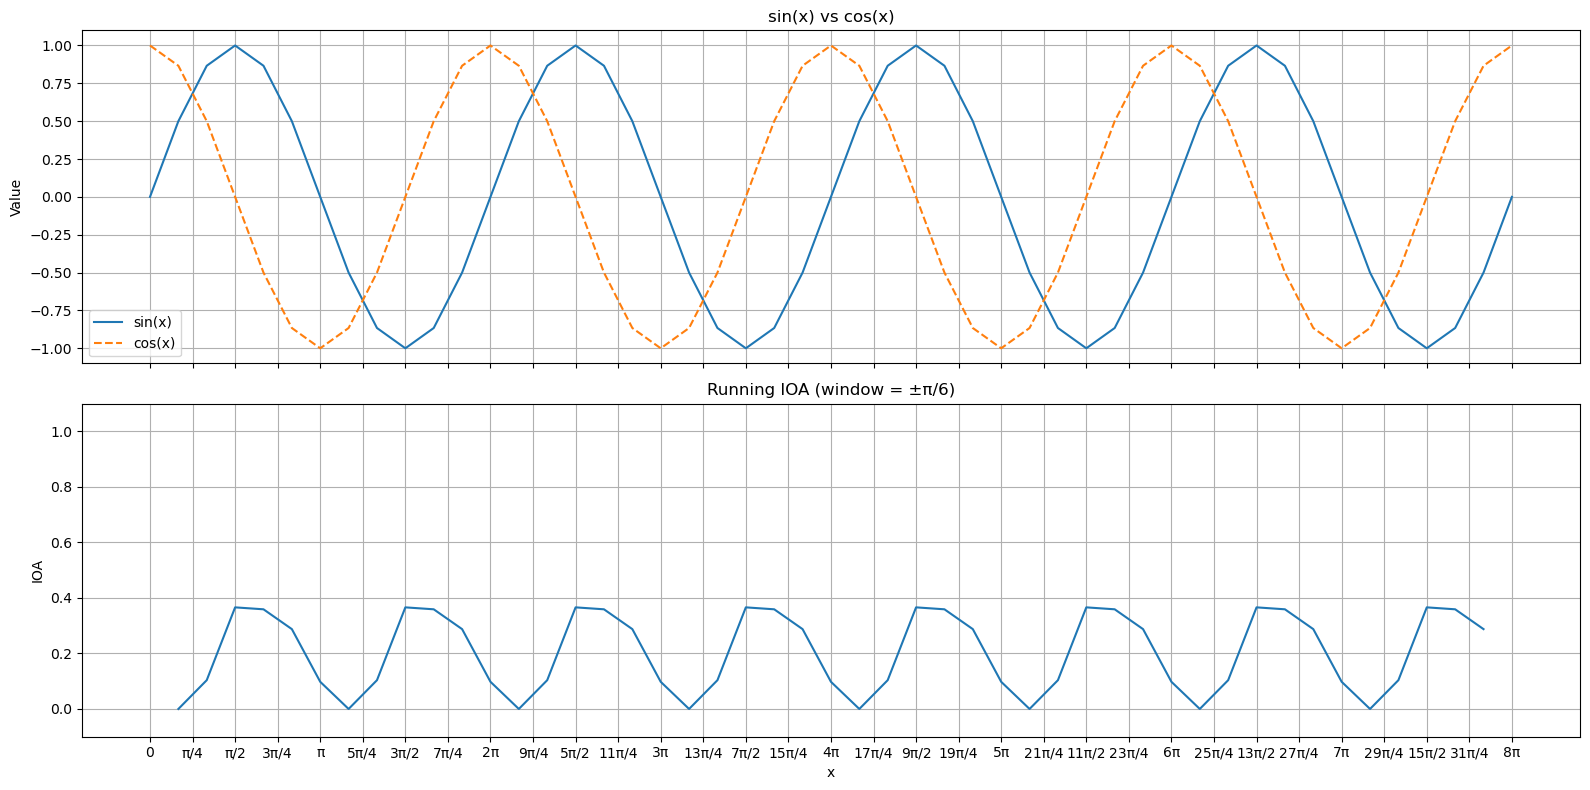

In [27]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ----------------------------
# Generate data
# ----------------------------
k_vals = np.arange(49)
x_vals = k_vals * math.pi / 6

sin_vals = np.sin(x_vals)
cos_vals = np.cos(x_vals)

# ----------------------------
# Running IOA (±π/6 window)
# ----------------------------
ioa_vals = []

for i in range(len(sin_vals)):
    if i == 0 or i == len(sin_vals) - 1:
        ioa_vals.append(np.nan)
        continue

    model = sin_vals[i-1:i+2]
    ref = cos_vals[i-1:i+2]

    numerator = np.sum((model - ref) ** 2)
    denominator = np.sum(
        (np.abs(model - np.mean(ref)) +
         np.abs(ref - np.mean(ref))) ** 2
    )

    ioa = 1 - numerator / denominator if denominator != 0 else np.nan
    ioa_vals.append(ioa)

ioa_vals = np.array(ioa_vals)

# ----------------------------
# Plotting (clean alignment)
# ----------------------------
fig, axs = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: sin and cos
axs[0].plot(x_vals, sin_vals, label="sin(x)")
axs[0].plot(x_vals, cos_vals, label="cos(x)", linestyle="--")
axs[0].set_title("sin(x) vs cos(x)")
axs[0].set_ylabel("Value")
axs[0].legend()
axs[0].grid(True)

# Bottom: IOA
axs[1].plot(x_vals, ioa_vals)
axs[1].set_title("Running IOA (window = ±π/6)")
axs[1].set_xlabel("x")
axs[1].set_ylabel("IOA")
axs[1].set_ylim(-0.1, 1.1)
axs[1].grid(True)

import matplotlib.ticker as ticker

# Define tick positions (0 to 8π in steps of π/4)
pi = math.pi
ticks = np.arange(0, 8*pi + pi/4, pi/4)

# Function to format labels as fractions of π
def format_pi_label(x):
    frac = x / pi
    if frac == 0:
        return "0"
    elif frac == 1:
        return "π"
    elif frac.is_integer():
        return f"{int(frac)}π"
    else:
        # convert to fraction like 1/4, 3/2, etc.
        from fractions import Fraction
        f = Fraction(frac).limit_denominator(8)
        if f.numerator == 1:
            return f"π/{f.denominator}"
        elif f.denominator == 1:
            return f"{f.numerator}π"
        else:
            return f"{f.numerator}π/{f.denominator}"

labels = [format_pi_label(t) for t in ticks]

# Apply to BOTH subplots
axs[0].set_xticks(ticks)
axs[0].set_xticklabels(labels)

axs[1].set_xticks(ticks)
axs[1].set_xticklabels(labels)

plt.tight_layout()
plt.show()

# -Sinx vs Cosx

In [41]:
import csv
import numpy as np

# Read sin values and negate them -> -sin(x)
neg_sin_values = []
with open("sin_values.csv", "r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        neg_sin_values.append(-float(row["sin(x)"]))

# Read cos values
cos_values = []
with open("cos_values.csv", "r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        cos_values.append(float(row["cos(x)"]))

model_valid = np.array(neg_sin_values)
ref_valid = np.array(cos_values)

# IOA (Willmott 1981)
numerator = np.sum((model_valid - ref_valid) ** 2)

denominator = np.sum(
    (np.abs(model_valid - np.mean(ref_valid)) +
     np.abs(ref_valid - np.mean(ref_valid))) ** 2
)

ioa = 1 - numerator / denominator if denominator != 0 else np.nan

print(ioa)

0.3669729713219897


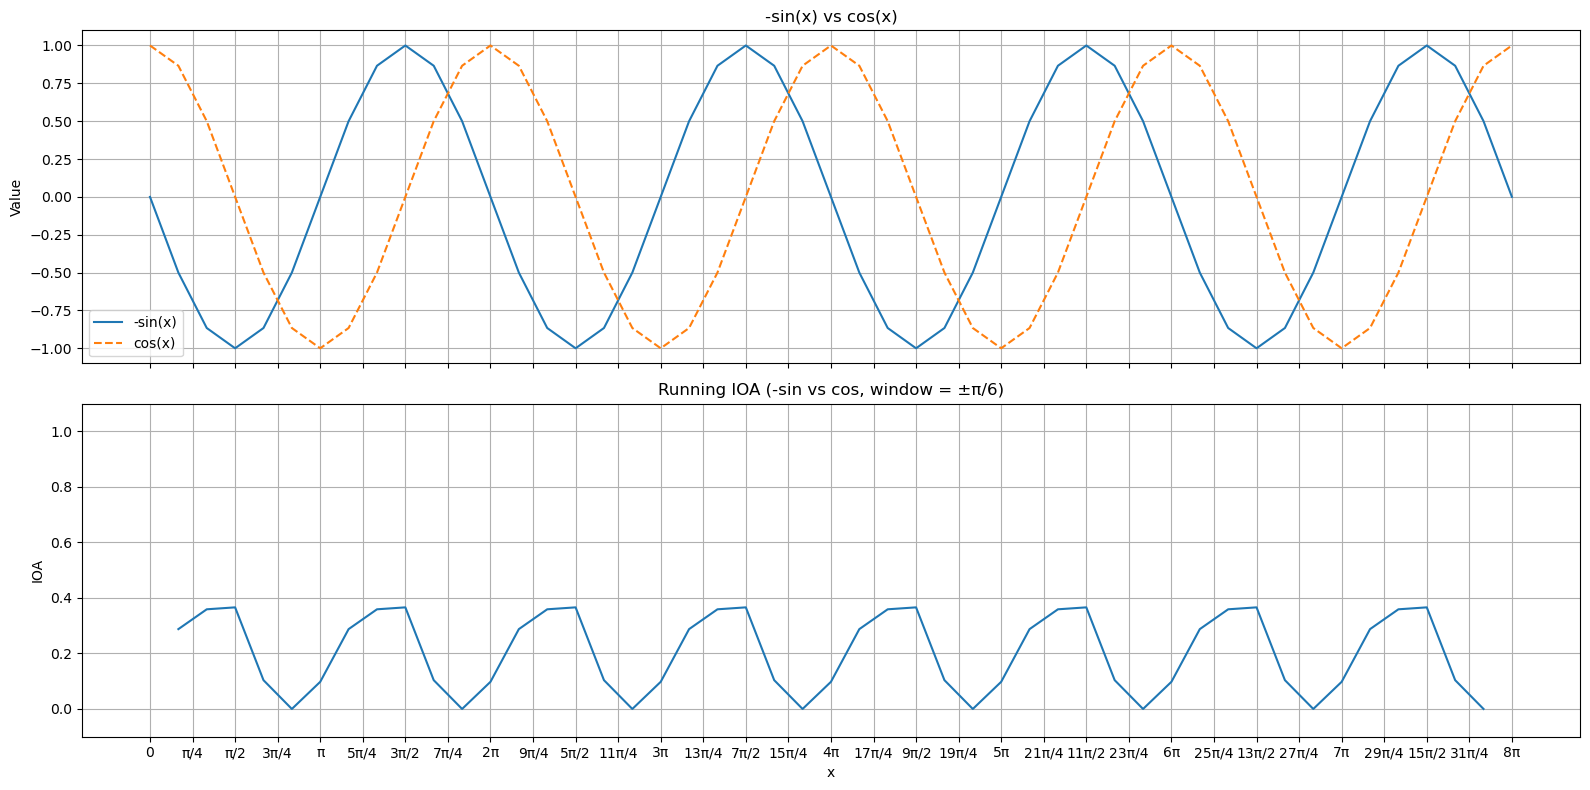

In [26]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ----------------------------
# Generate data
# ----------------------------
k_vals = np.arange(49)
x_vals = k_vals * math.pi / 6

sin_vals = np.sin(x_vals)
neg_sin_vals = -sin_vals
cos_vals = np.cos(x_vals)

# ----------------------------
# Running IOA (±π/6 window)
# ----------------------------
ioa_vals = []

for i in range(len(sin_vals)):
    if i == 0 or i == len(sin_vals) - 1:
        ioa_vals.append(np.nan)
        continue

    model = neg_sin_vals[i-1:i+2]
    ref = cos_vals[i-1:i+2]

    numerator = np.sum((model - ref) ** 2)
    denominator = np.sum(
        (np.abs(model - np.mean(ref)) +
         np.abs(ref - np.mean(ref))) ** 2
    )

    ioa = 1 - numerator / denominator if denominator != 0 else np.nan
    ioa_vals.append(ioa)

ioa_vals = np.array(ioa_vals)

# ----------------------------
# Plotting (clean alignment)
# ----------------------------
fig, axs = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: -sin and cos
axs[0].plot(x_vals, neg_sin_vals, label="-sin(x)")
axs[0].plot(x_vals, cos_vals, label="cos(x)", linestyle="--")
axs[0].set_title("-sin(x) vs cos(x)")
axs[0].set_ylabel("Value")
axs[0].legend()
axs[0].grid(True)

# Bottom: running IOA
axs[1].plot(x_vals, ioa_vals)
axs[1].set_title("Running IOA (-sin vs cos, window = ±π/6)")
axs[1].set_xlabel("x")
axs[1].set_ylabel("IOA")
axs[1].set_ylim(-0.1, 1.1)
axs[1].grid(True)

import matplotlib.ticker as ticker

# Define tick positions (0 to 8π in steps of π/4)
pi = math.pi
ticks = np.arange(0, 8*pi + pi/4, pi/4)

# Function to format labels as fractions of π
def format_pi_label(x):
    frac = x / pi
    if frac == 0:
        return "0"
    elif frac == 1:
        return "π"
    elif frac.is_integer():
        return f"{int(frac)}π"
    else:
        # convert to fraction like 1/4, 3/2, etc.
        from fractions import Fraction
        f = Fraction(frac).limit_denominator(8)
        if f.numerator == 1:
            return f"π/{f.denominator}"
        elif f.denominator == 1:
            return f"{f.numerator}π"
        else:
            return f"{f.numerator}π/{f.denominator}"

labels = [format_pi_label(t) for t in ticks]

# Apply to BOTH subplots
axs[0].set_xticks(ticks)
axs[0].set_xticklabels(labels)

axs[1].set_xticks(ticks)
axs[1].set_xticklabels(labels)


plt.tight_layout()
plt.show()